In [72]:
library(dplyr)
library(ggplot2)
library(ggpubr)
library(clubSandwich)
library(lme4)
library(clubSandwich)
library(ggpubr)
library(patchwork)
library(dplyr)
library(ggplot2)
library(ggpubr)
library(ggforce)


In [73]:
#Here we import CNVs dataset
#This CNVs call set is based on wakhan tool
#cnv_summary <- read.delim2("/home/mjehangir/telomere-sv-analysis/data//cnvs_summary_rate_prop_pq.tsv", header = TRUE)
cnv_summary <- read.delim2("/home/mjehangir/telomere-sv-analysis/data/wakhan_cnvs_summary_rate_prop_pq.tsv", header = TRUE)

head(cnv_summary)

,ID,chrom,Arm,Gain_Loss,Arm_Length,total_cnv_length,segment_count,arm_length_mb,cnv_rate_per_mb,cnv_proportion_per_mb,arm
,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>
1,2436A,chr10,q,Loss,94108943,18.647833,5,94.108943,0.0531299134876055,0.198151550804263,chr10q
2,2436A,chr11,p,Loss,52743313,0.000611,1,52.743313,0.01895974945677,1.15844069180865e-05,chr11p
3,2436A,chr18,q,Loss,62092914,0.400654,1,62.092914,0.0161048972512387,0.00645249150329778,chr18q
4,2436A,chr4,p,Loss,52452474,3.999999,1,52.452474,0.0190648776643024,0.0762594915923318,chr4p
5,2436A,chrX,p,Loss,59373565,57.999999,2,59.373565,0.0336850246401745,0.976865697722547,chrXp
6,2436A,chrX,q,Loss,94886001,90.249999,2,94.886001,0.0210779248669148,0.951141349080567,chrXq


In [74]:
colnames(cnv_summary)

[1] "ID"                    "chrom"                 "Arm"                  
 [4] "Gain_Loss"             "Arm_Length"            "total_cnv_length"     
 [7] "segment_count"         "arm_length_mb"         "cnv_rate_per_mb"      
[10] "cnv_proportion_per_mb" "arm"

In [75]:
#and load the telomere dataset
telomere_data <- read.delim2("/home/mjehangir/telomere-sv-analysis/data/telomere_data_fig3_cnvs.tsv", header = TRUE)
head(telomere_data)

,Sample_prefix,chr,final_average_TL_p75,chr_order,arm,final_average_TL_p75_kb,direction,TL_group
,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>
1,2436A,chr1p,5221,1,p,5.221,Negative,Other
2,2436A,chr1q,5051.16666666667,1,q,5.05116666666667,Negative,Other
3,3188,chr1p,1642.5,1,p,1.6425,Negative,Short TL
4,3188,chr1q,3086.5,1,q,3.0865,Negative,Short TL
5,3988,chr1p,2347.5,1,p,2.3475,Negative,Other
6,3988,chr1q,5083,1,q,5.083,Negative,Other


In [76]:
nrow(telomere_data)
unique(telomere_data$TL_group)

[1] 831

[1] "Other"    "Short TL"

In [77]:
# To format chr arms, we make new variable and the add matching 'arm' from the chrom and Arm
cnv_data <- cnv_summary %>%
  mutate(arm = paste0(chrom, Arm))  # e.g., "chr10q"

In [78]:
head(cnv_data)

,ID,chrom,Arm,Gain_Loss,Arm_Length,total_cnv_length,segment_count,arm_length_mb,cnv_rate_per_mb,cnv_proportion_per_mb,arm
,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>
1,2436A,chr10,q,Loss,94108943,18.647833,5,94.108943,0.0531299134876055,0.198151550804263,chr10q
2,2436A,chr11,p,Loss,52743313,0.000611,1,52.743313,0.01895974945677,1.15844069180865e-05,chr11p
3,2436A,chr18,q,Loss,62092914,0.400654,1,62.092914,0.0161048972512387,0.00645249150329778,chr18q
4,2436A,chr4,p,Loss,52452474,3.999999,1,52.452474,0.0190648776643024,0.0762594915923318,chr4p
5,2436A,chrX,p,Loss,59373565,57.999999,2,59.373565,0.0336850246401745,0.976865697722547,chrXp
6,2436A,chrX,q,Loss,94886001,90.249999,2,94.886001,0.0210779248669148,0.951141349080567,chrXq


In [79]:
nrow(cnv_data)
nrow(cnv_summary)

[1] 339

[1] 339

In [80]:
# Merge telomere and CNV data mathcing sample ID and arm and skip NA (arms with no telomeres data X chromosomes arms)
merged_cnv_data <- cnv_data %>%
  left_join(telomere_data, by = c("ID" = "Sample_prefix", "arm" = "chr")) %>%
  filter(!is.na(final_average_TL_p75))  # Filter out rows with missing telomere info

# View result
head(merged_cnv_data)

,ID,chrom,Arm,Gain_Loss,Arm_Length,total_cnv_length,segment_count,arm_length_mb,cnv_rate_per_mb,cnv_proportion_per_mb,arm,final_average_TL_p75,chr_order,arm.y,final_average_TL_p75_kb,direction,TL_group
,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>
1,2436A,chr10,q,Loss,94108943,18.647833,5,94.108943,0.0531299134876055,0.198151550804263,chr10q,2732.75,10,q,2.73275,Positive,Other
2,2436A,chr11,p,Loss,52743313,0.000611,1,52.743313,0.01895974945677,1.15844069180865e-05,chr11p,6766,11,p,6.766,Negative,Other
3,2436A,chr18,q,Loss,62092914,0.400654,1,62.092914,0.0161048972512387,0.00645249150329778,chr18q,3629.5,18,q,3.6295,Positive,Other
4,2436A,chr4,p,Loss,52452474,3.999999,1,52.452474,0.0190648776643024,0.0762594915923318,chr4p,5788.25,4,p,5.78825,Negative,Other
5,3188,chr1,p,Loss,124048267,119.99999,11,124.048267,0.0886751606130862,0.967365307892612,chr1p,1642.5,1,p,1.6425,Negative,Short TL
6,3188,chr10,q,Loss,94108943,43.493116,6,94.108943,0.0637558961851266,0.462157098077278,chr10q,3496.5,10,q,3.4965,Positive,Short TL


In [81]:
nrow(merged_cnv_data)
nrow(cnv_data)


[1] 291

[1] 339

In [82]:
# check for duplicate rows per arm per sample
# for example chr14q, no duplicates 
merged_cnv_data %>%
  filter(ID == "3188", chrom == "chr14", Arm =="q") %>%
  select(ID, chrom, Arm, Gain_Loss, cnv_rate_per_mb, final_average_TL_p75_kb, TL_group)

ID,chrom,Arm,Gain_Loss,cnv_rate_per_mb,final_average_TL_p75_kb,TL_group
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
3188,chr14,q,Gain,0.267376012256338,2.626,Short TL
3188,chr14,q,Loss,0.73528403370493,2.626,Short TL


In [87]:
head(merged_cnv_data, 2)

,ID,chrom,Arm,Gain_Loss,Arm_Length,total_cnv_length,segment_count,arm_length_mb,cnv_rate_per_mb,cnv_proportion_per_mb,arm,final_average_TL_p75,chr_order,arm.y,final_average_TL_p75_kb,direction,TL_group
,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>
1,2436A,chr10,q,Loss,94108943,18.647833,5,94.108943,0.0531299134876055,0.198151550804263,chr10q,2732.75,10,q,2.73275,Positive,Other
2,2436A,chr11,p,Loss,52743313,0.000611,1,52.743313,0.01895974945677,1.15844069180865e-05,chr11p,6766,11,p,6.766,Negative,Other


In [89]:
write.table(merged_cnv_data, file = "/home/mjehangir/telomere-sv-analysis/data/merged_wakhan_cnv_telomere_data.tsv", sep = "\t", quote = FALSE, row.names = FALSE)

In [83]:
# compare the CNV gain and loss between short vs other
# --- 1. plot susbet data ---
#reshape the data into linear format
df_linear <- merged_cnv_data %>%
  mutate(
    cnv_rate_num = as.numeric(as.character(cnv_rate_per_mb)),
    cnv_prop_num = as.numeric(as.character(cnv_proportion_per_mb))
  ) %>%
  group_by(ID, chrom, Arm, Gain_Loss) %>%
  summarise(
    Total_Rate = sum(cnv_rate_num, na.rm = TRUE),
    Total_Prop = sum(cnv_prop_num, na.rm = TRUE),
    TL_group   = first(TL_group),
    .groups = "drop"
  ) %>%
  mutate(
    TL_group = factor(TL_group, levels = c("Other", "Short TL"))
  )

In [84]:
head(df_linear)

ID,chrom,Arm,Gain_Loss,Total_Rate,Total_Prop,TL_group
<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<fct>
2436A,chr10,q,Loss,0.05312991,1.981516e-01,Other
2436A,chr11,p,Loss,0.01895975,1.158441e-05,Other
2436A,chr18,q,Loss,0.01610490,6.452492e-03,Other
2436A,chr4,p,Loss,0.01906488,7.625949e-02,Other
3188,chr1,p,Loss,0.08867516,9.673653e-01,Short TL
3188,chr10,q,Loss,0.06375590,4.621571e-01,Short TL


In [85]:
# --- 2. THE PLOTTING LOOP function for CNV type as plot panels---
metrics <- list(Total_Rate = "CNV rate (Events/Mb)", Total_Prop = "CNV proportion")
types <- c("Gain", "Loss")
plot_list <- list()

for (m_name in names(metrics)) {
  for (t in types) {
    df_sub <- df_linear %>% filter(Gain_Loss == t)
    
    # Calculate N for group labels
    n_counts <- df_sub %>% 
      group_by(TL_group) %>% 
      summarise(n = n()) %>% 
      mutate(label = paste0(TL_group, "\n(n=", n, ")"))
    
    df_plot <- df_sub %>% left_join(n_counts, by = "TL_group")
    
    # Wilcoxon test 
    wt_res <- wilcox.test(as.formula(paste(m_name, "~ TL_group")), data = df_plot)
    p_val <- format.pval(wt_res$p.value, digits = 2)
    
    p <- ggplot(df_plot, aes(x = label, y = !!sym(m_name), fill = TL_group)) +
      # Sina plot showing raw density
      geom_sina(aes(color = TL_group), alpha = 0.3, size = 1.8) +
      # Boxplot for summary stats
      geom_boxplot(width = 0.25, outlier.shape = NA, alpha = 0.7, 
                   color = "black", fatten = 2) +
      
      stat_compare_means(method = "wilcox.test", label = "p.signif", label.x = 1.5) +
      
      scale_fill_manual(values = c("Other" = "steelblue1", "Short TL" = "darkred")) +
      scale_color_manual(values = c("Other" = "steelblue1", "Short TL" = "darkred")) +
      
      # Use a limit or expansion to ensure outliers don't hide the boxplots
      coord_cartesian(ylim = c(0, quantile(df_plot[[m_name]], 0.98, na.rm=T) * 1.5)) +
      
      labs(title = paste(t, "Events"),
           subtitle = paste0("Wilcoxon p = ", p_val),
           y = metrics[[m_name]], x = NULL) +
      theme_classic(base_size = 8) +
      theme(
        legend.position = "none",
        plot.title = element_text(face = "bold", size = 8),
        axis.text.x = element_text(face = "bold", color = "black")
      )
    
    plot_list[[paste(m_name, t)]] <- p
  }
}

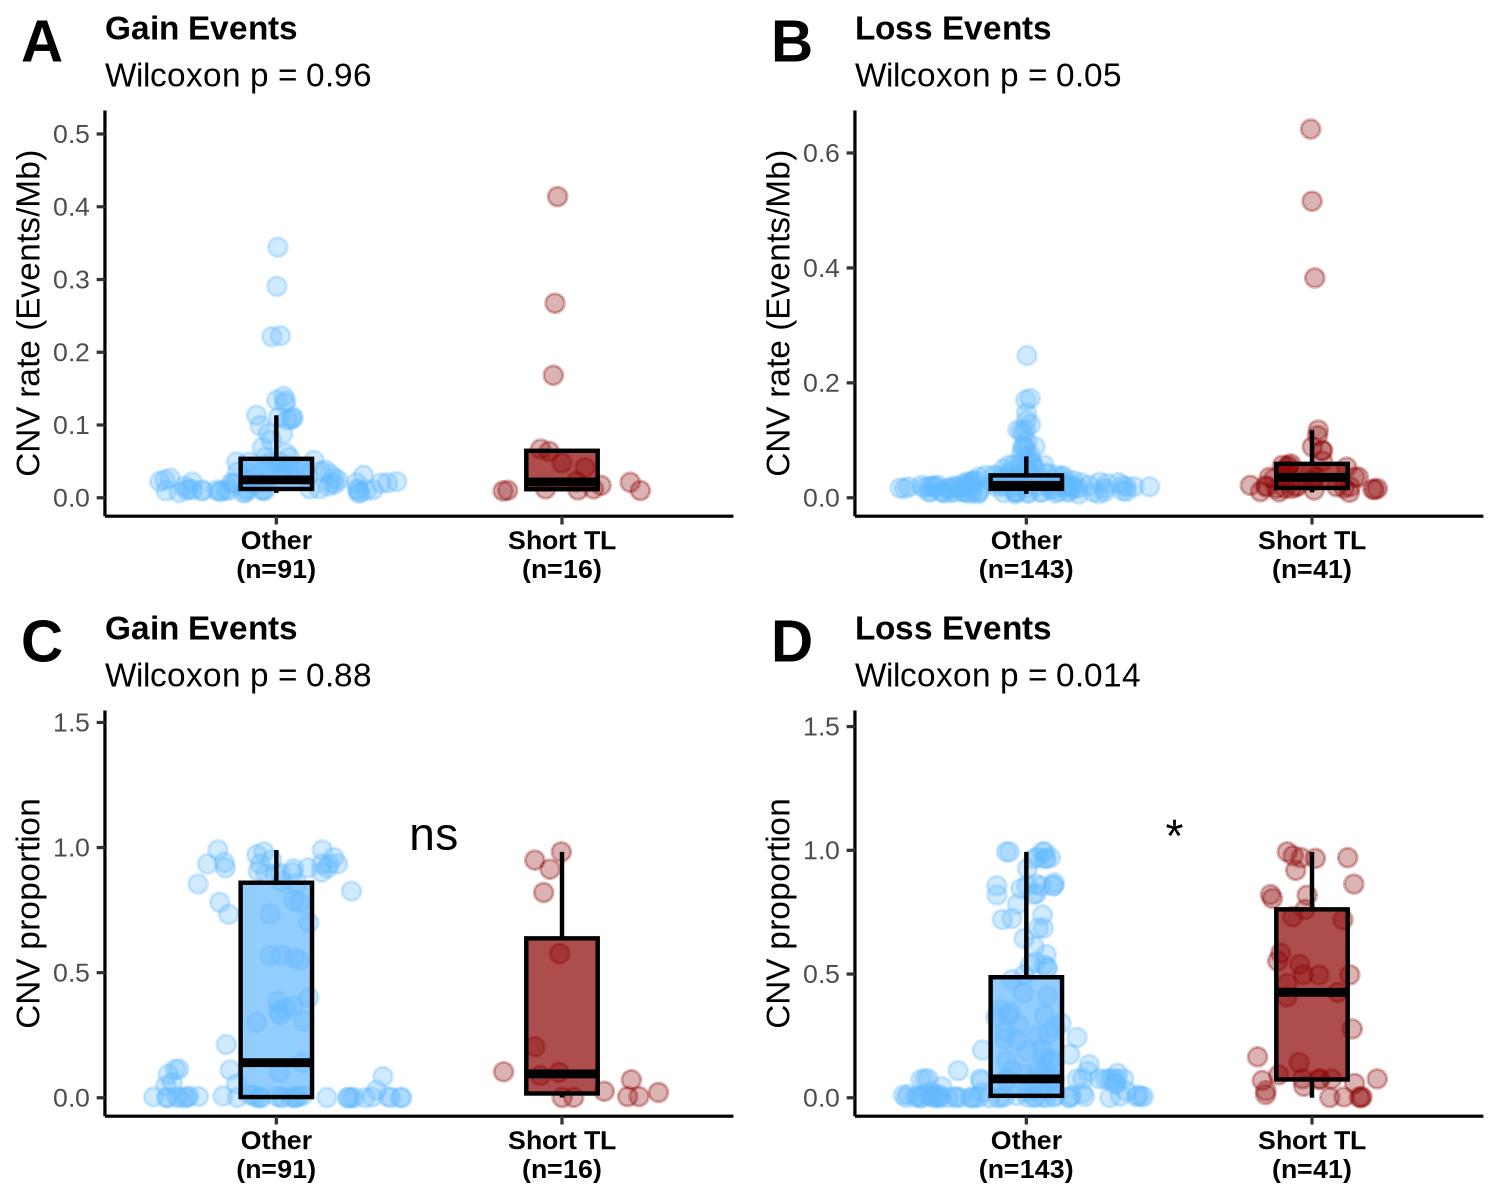

In [86]:
# --- 3. plot ---
options(repr.plot.width = 5, repr.plot.height = 4, repr.plot.res = 300)
main_panel_linear <- ggarrange(plotlist = plot_list, ncol = 2, nrow = 2, labels = "AUTO")
print(main_panel_linear)

The above wakhan based comparative analysis does not show consistent result for the 
for DNA copy based CNVs callset